# TRAIN NORMAL ONLY

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

In [2]:
# =====================================================================
# 1. PERSIAPAN DATA & FILTERING
# =====================================================================
EXCEL_PATH = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur.xlsx' 
df = pd.read_excel(EXCEL_PATH)

# Membersihkan data dari nilai kosong
df = df.dropna(subset=['Anemia_Class', 'Hemoglobin', 'Age', 'Gender'])

print(f"Total data pasien awal: {len(df)}")
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

# MEMFILTER HANYA KELAS NORMAL (Kelas 3.0)
df_normal = df[df['Anemia_Class'] == 3.0].copy()

print(f"Total data pasien yang akan diproses: {len(df_normal)}")
display(df_normal.head())

Total data pasien awal: 211
Total data pasien yang akan diproses: 121


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
7,India,8,32,1,162.132738,73.928369,129.074785,112.465995,167.743461,129.074785,167.676016,141.685578,162.520175,13.0,3
10,India,11,38,1,166.634443,105.015022,117.483334,133.295462,158.613323,117.483334,159.735414,96.081642,167.126447,13.2,3
20,India,21,21,1,164.644537,82.954968,121.740473,119.009910,166.488021,121.740473,164.030110,129.851308,164.723084,14.8,3
23,India,24,23,0,146.725836,82.162029,124.931934,110.652403,158.487636,124.931934,166.636412,113.765995,146.890867,13.4,3
26,India,27,48,0,162.559338,110.957976,115.488953,136.073423,155.016338,115.488953,154.981024,87.229894,165.750824,12.2,3



=== ANALISIS PEARSON CORRELATION (PCC) KELAS NORMAL ===


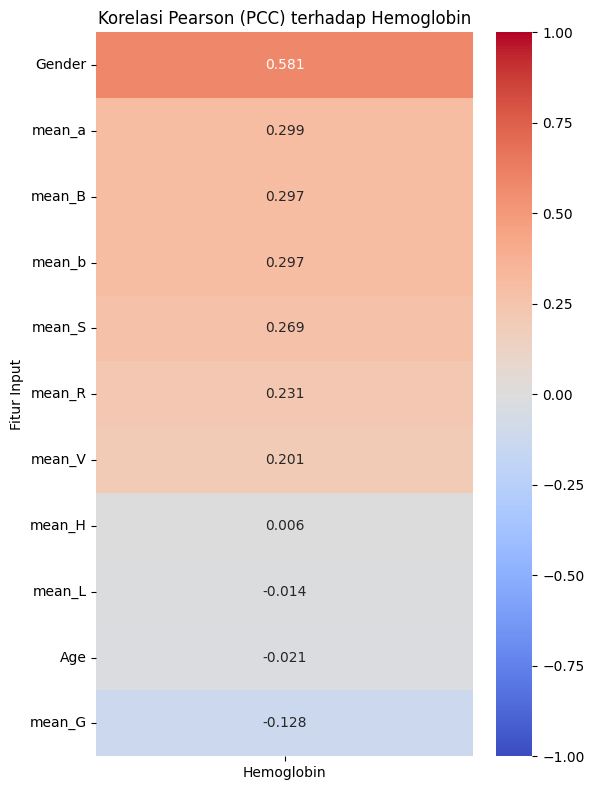

In [3]:
# =====================================================================
# 2. ANALISIS FITUR (PCC) KHUSUS KELAS NORMAL
# =====================================================================
print("\n=== ANALISIS PEARSON CORRELATION (PCC) KELAS NORMAL ===")
feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V']

# Menghitung matriks korelasi hanya pada dataframe kelas normal
corr_matrix_normal = df_normal[feature_columns + ['Hemoglobin']].corr(method='pearson')

# Memfokuskan tampilan HANYA pada kolom Hemoglobin dan mengurutkannya
corr_with_hb_normal = corr_matrix_normal[['Hemoglobin']].drop('Hemoglobin').sort_values(by='Hemoglobin', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_with_hb_normal, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Korelasi Pearson (PCC) terhadap Hemoglobin')
plt.ylabel('Fitur Input')
plt.tight_layout()
plt.show()

In [10]:
# =====================================================================
# 3. SPLITTING DATA KELAS NORMAL
# =====================================================================
X_normal = df_normal[feature_columns]
y_normal = df_normal['Hemoglobin']

X_train, X_test, y_train, y_test = train_test_split(X_normal, y_normal, test_size=0.2, random_state=42)

print(f'Jumlah data Normal untuk Training: {len(X_train)}')
print(f'Jumlah data Normal untuk Testing:  {len(X_test)}')

Jumlah data Normal untuk Training: 96
Jumlah data Normal untuk Testing:  25


In [8]:
# =====================================================================
# 4. INISIALISASI & PARAMETER MODEL
# =====================================================================
model_params = {
    'MLR': {}, 
    'SVR': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    'Random Forest': {'max_depth': 4, 'n_estimators': 20, 'random_state': 42},
    'Gradient Boosting': {'max_depth': 4, 'learning_rate': 0.01, 'n_estimators': 20, 'random_state': 42}
}

models = {
    'MLR': make_pipeline(StandardScaler(), LinearRegression(**model_params['MLR'])),
    'SVR': make_pipeline(StandardScaler(), SVR(**model_params['SVR'])),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(**model_params['Random Forest'])),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(**model_params['Gradient Boosting']))
}

In [11]:
# =====================================================================
# 5. PELATIHAN DAN EVALUASI (TRAINING)
# =====================================================================
results = {}
predictions_dict = {}

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred 
    
    # Hitung Error
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE (Error g/dL)': mae, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
print("\n=== PERBANDINGAN PERFORMA MODEL (KELAS NORMAL) ===")
display(results_df.sort_values(by='MAE (Error g/dL)'))


=== PERBANDINGAN PERFORMA MODEL (KELAS NORMAL) ===


,MAE (Error g/dL),R2 Score
MLR,0.822932,0.264119
Random Forest,0.897623,0.085118
SVR,0.901459,0.184832
Gradient Boosting,1.020697,-0.004769


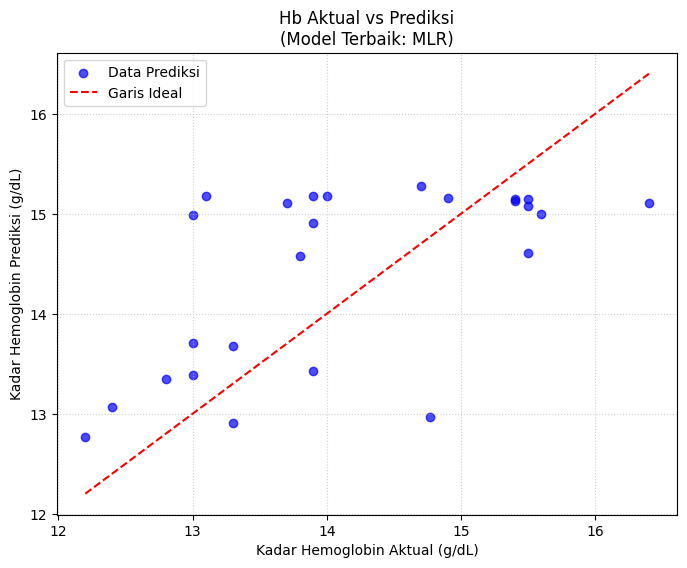

In [12]:
#cell buat visualisasi
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_y_pred = predictions_dict[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.7, color='blue', label='Data Prediksi')

min_val = min(min(y_test), min(best_y_pred))
max_val = max(max(y_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')

plt.title(f'Hb Aktual vs Prediksi\n(Model Terbaik: {best_model_name})')
plt.xlabel('Kadar Hemoglobin Aktual (g/dL)')
plt.ylabel('Kadar Hemoglobin Prediksi (g/dL)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [12]:
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_model = models[best_model_name]

save_dir = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\models\weights'
os.makedirs(save_dir, exist_ok=True)

# Simpan model dengan nama spesifik agar tidak menimpa model lama
save_path = os.path.join(save_dir, 'hb_model_normal_only.pkl') 

joblib.dump(best_model, save_path)

print(f'\n[BERHASIL] Model {best_model_name} (Khusus Normal) telah disimpan di: {save_path}')


[BERHASIL] Model MLR (Khusus Normal) telah disimpan di: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\models\weights\hb_model_normal_only.pkl
